# Day 3 — Advanced Exploratory Data Analysis (EDA) & Visualizations

Performs deep exploratory analysis and exports **16** publication-quality charts to `reports/charts/`.


In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = [12, 6.5]
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 10

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
DB_PATH = PROJECT_ROOT / 'data' / 'db' / 'bluestock_mf.db'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORTS_CHARTS_DIR = PROJECT_ROOT / 'reports' / 'charts'
REPORTS_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

assert DB_PATH.exists(), f'SQLite DB not found at {DB_PATH}. Run Day 2 first.'
conn = sqlite3.connect(str(DB_PATH))

def read_fact(table_name: str) -> pd.DataFrame:
    return pd.read_sql_query(f'SELECT * FROM {table_name}', conn)

fact_nav = read_fact('fact_nav')
fact_aum = read_fact('fact_aum')
fact_sip_inflows = read_fact('fact_sip_inflows')
fact_transactions = read_fact('fact_transactions')
fact_performance = read_fact('fact_performance')
dim_fund = read_fact('dim_fund')

clean_category_inflows = pd.read_csv(PROCESSED_DIR / 'clean_category_inflows.csv')
clean_holdings = pd.read_csv(PROCESSED_DIR / 'clean_holdings.csv')
clean_folio_count = pd.read_csv(PROCESSED_DIR / 'clean_folio_count.csv')

print('Connected DB:', DB_PATH)
print('fact_nav columns:', list(fact_nav.columns))
print('dim_fund columns:', list(dim_fund.columns))


Connected DB: /Users/harshavardhan/Desktop/bluestock_mf_capstone/data/db/bluestock_mf.db
fact_nav columns: ['scheme_code', 'date', 'nav', 'fund_house', 'scheme_category', 'scheme_name']
dim_fund columns: ['scheme_code', 'scheme_name', 'fund_house', 'scheme_category', 'raw_json']


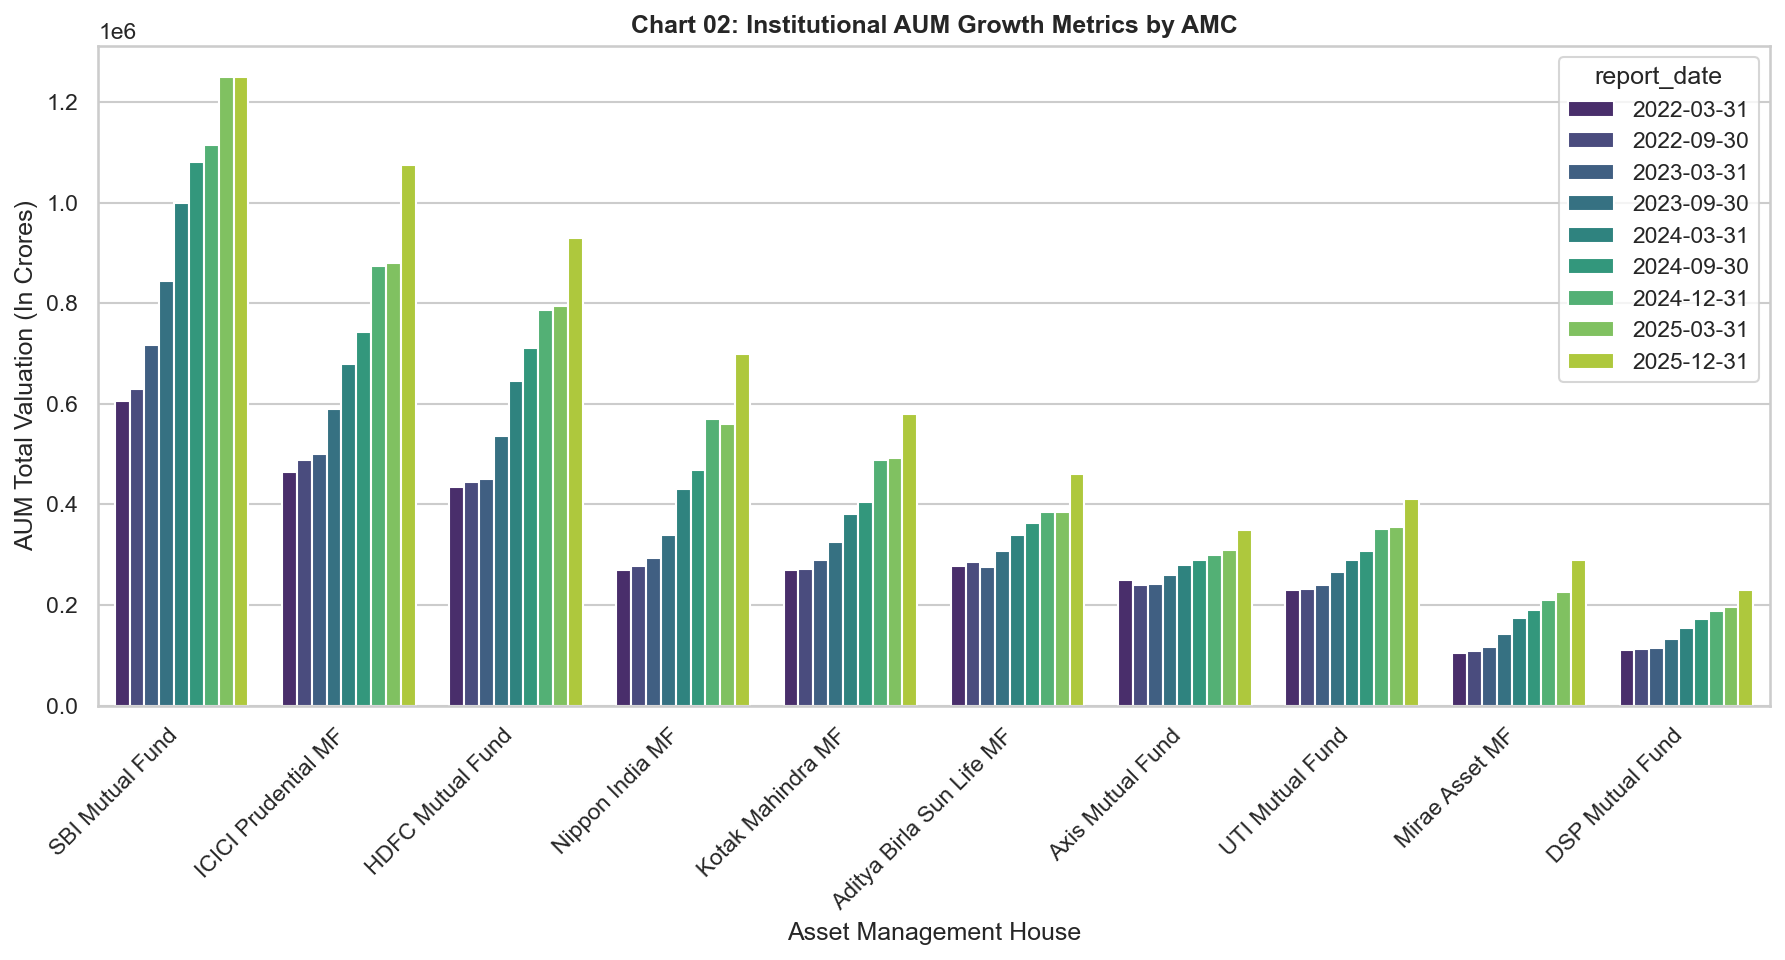

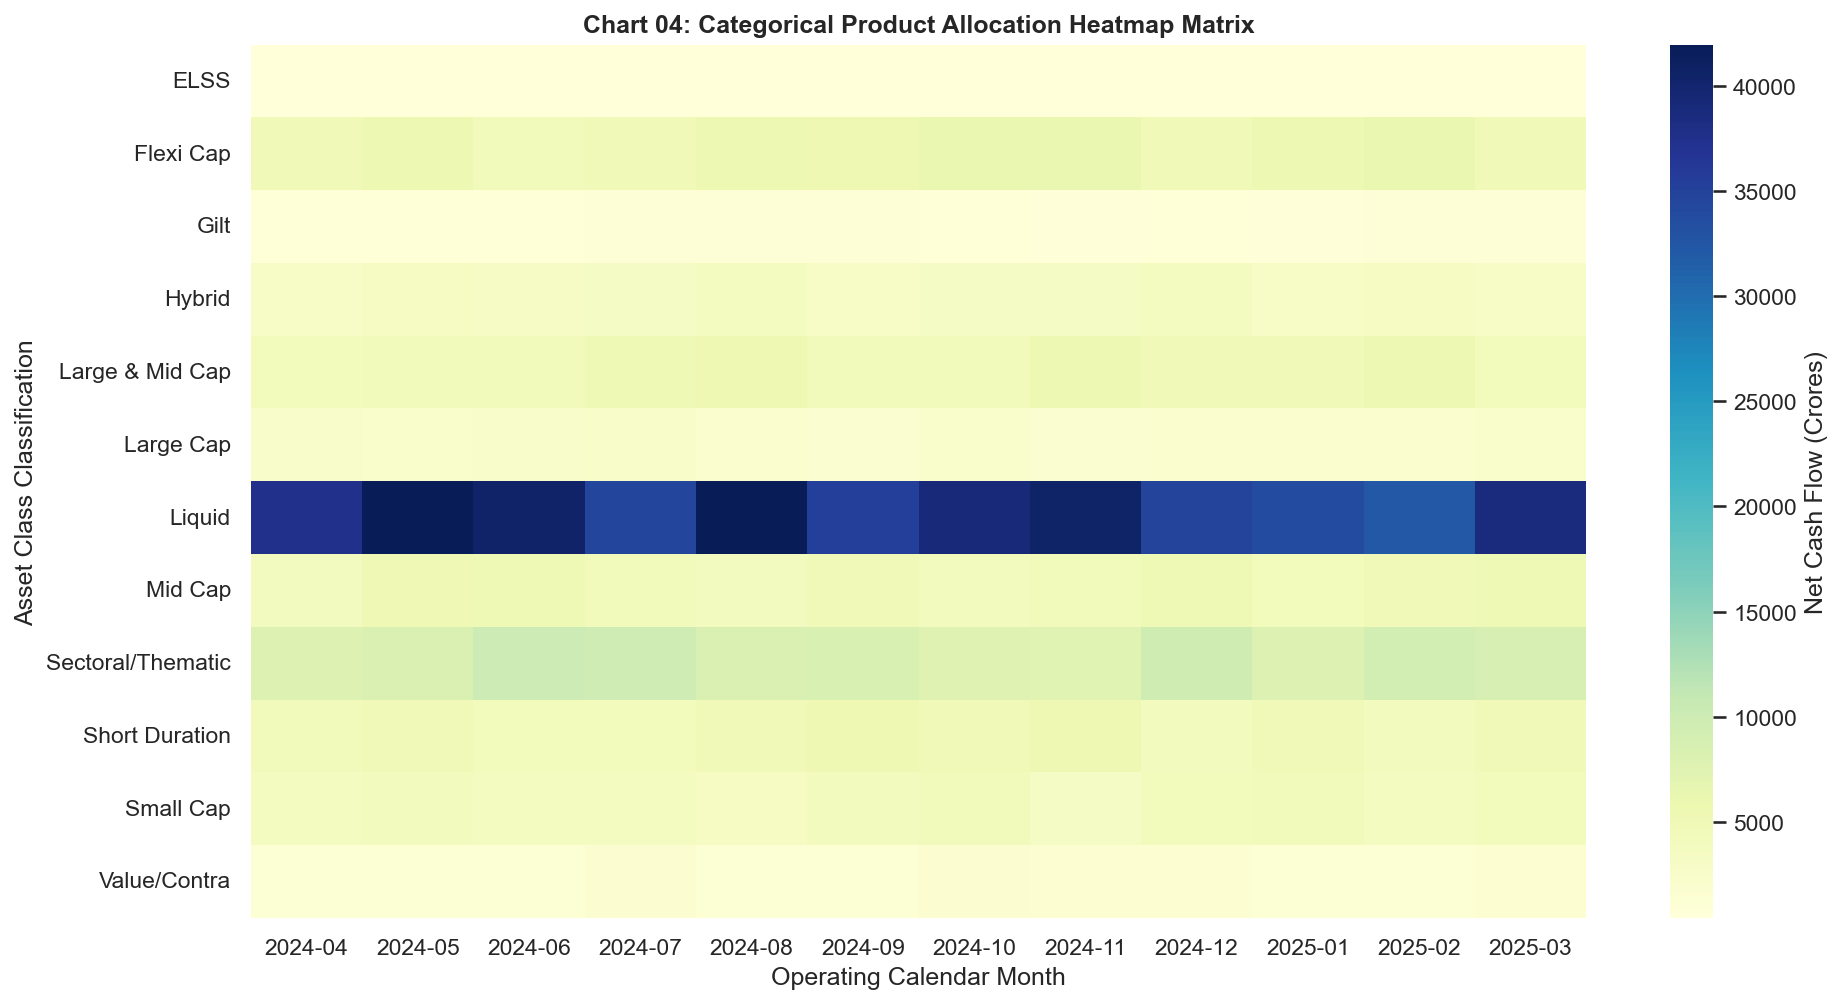

In [2]:
# Chart 01: Normalized NAV Trend
sampled_codes = [119551, 120503, 118632, 119092, 120841]
nav_id_col = 'scheme_code' if 'scheme_code' in fact_nav.columns else 'amfi_code'
df_nav_slice = fact_nav[fact_nav[nav_id_col].isin(sampled_codes)].copy()
df_nav_slice['date'] = pd.to_datetime(df_nav_slice['date'])
df_nav_slice = df_nav_slice.sort_values(['scheme_code', 'date'])
df_nav_slice['normalized_nav'] = (
    df_nav_slice.groupby('scheme_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

fig_nav = px.line(df_nav_slice, x='date', y='normalized_nav', color='scheme_code',
                 title='Chart 01: Normalized NAV Trajectory (Rebased to 100)')
fig_nav.update_layout(xaxis_title='Date', yaxis_title='Normalized NAV (Base=100)')
fig_nav.write_image(str(REPORTS_CHARTS_DIR / 'nav_trend.png'), width=1920, height=1080, scale=2)
fig_nav.show()

# Chart 02: AUM growth
plt.figure()
aum_hue = 'report_date' if 'report_date' in fact_aum.columns else None
sns.barplot(data=fact_aum, x='fund_house', y='aum_crore', hue=aum_hue, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Chart 02: Institutional AUM Growth Metrics by AMC', fontweight='bold')
plt.xlabel('Asset Management House')
plt.ylabel('AUM Total Valuation (In Crores)')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'aum_growth.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 03: SIP trend + milestone annotation (₹31,002 Cr peak)
sip_df = fact_sip_inflows.sort_values('month').copy()
peak_idx = sip_df['sip_inflow_crore'].idxmax()
peak_date = sip_df.loc[peak_idx, 'month']
peak_value = sip_df.loc[peak_idx, 'sip_inflow_crore']
fig_sip = px.line(sip_df, x='month', y='sip_inflow_crore', title='Chart 03: Monthly SIP Inflow Trend',
                  markers=True)
fig_sip.add_annotation(x=peak_date, y=peak_value, text='₹31,002 Cr Peak', showarrow=True,
                       arrowhead=2, bgcolor='yellow', ax=0, ay=-60)
fig_sip.update_layout(xaxis_title='Operating Month', yaxis_title='Injected Capital (In Crores)')
fig_sip.write_image(str(REPORTS_CHARTS_DIR / 'sip_trend.png'), width=1920, height=1080, scale=2)
fig_sip.show()

# Chart 04: Category heatmap
pivot_inflow = clean_category_inflows.pivot(index='category', columns='month', values='net_inflow_crore')
plt.figure(figsize=(13, 6.8))
sns.heatmap(pivot_inflow, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Net Cash Flow (Crores)'})
plt.title('Chart 04: Categorical Product Allocation Heatmap Matrix', fontweight='bold')
plt.xlabel('Operating Calendar Month')
plt.ylabel('Asset Class Classification')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'category_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


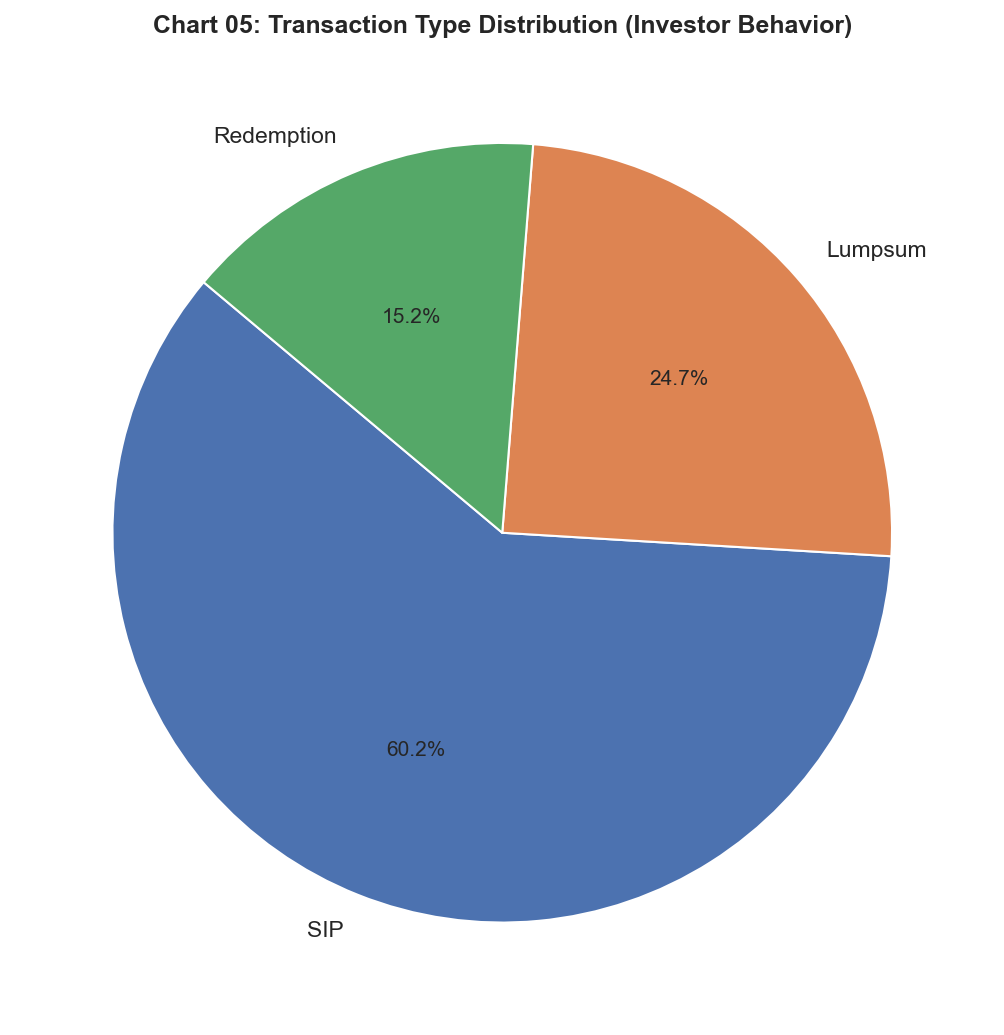

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_57572/1503047850.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fact_transactions, x='transaction_type', y='amount_inr', palette='Set2')


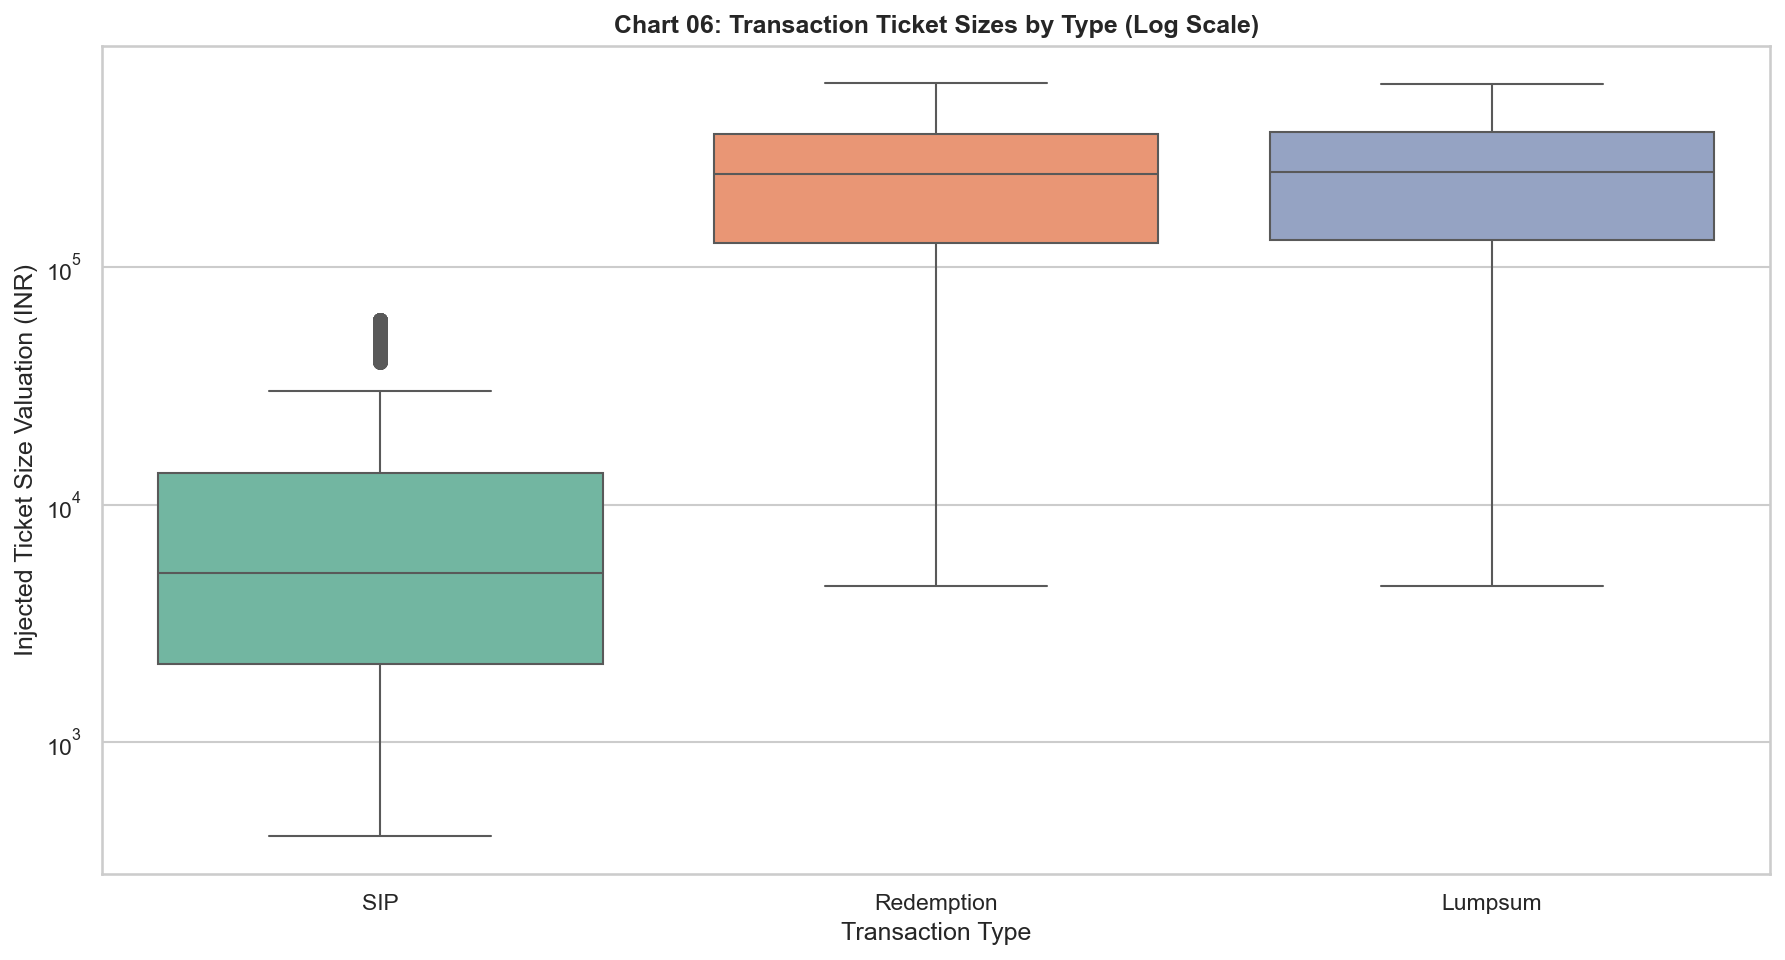

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_57572/1503047850.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fact_transactions, x='kyc_status', palette='muted')


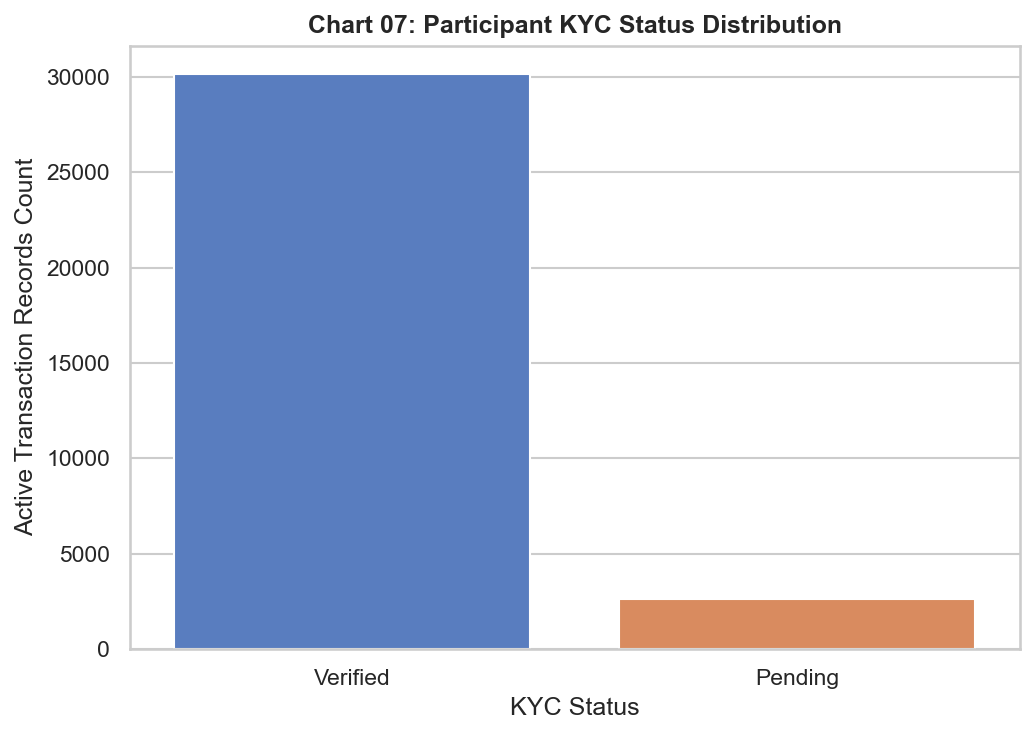

In [3]:
# Chart 05: Transaction Type Distribution (pie)
tx = fact_transactions.copy()
plt.figure(figsize=(7, 7))
type_dist = tx['transaction_type'].value_counts().dropna()
plt.pie(type_dist, labels=type_dist.index.astype(str), autopct='%1.1f%%', startangle=140)
plt.title('Chart 05: Transaction Type Distribution (Investor Behavior)', fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'demographics_age.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 06: Ticket sizes by transaction type (log)
plt.figure()
sns.boxplot(data=fact_transactions, x='transaction_type', y='amount_inr', palette='Set2')
plt.yscale('log')
plt.title('Chart 06: Transaction Ticket Sizes by Type (Log Scale)', fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Injected Ticket Size Valuation (INR)')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'demographics_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 07: KYC status distribution (supporting)
plt.figure(figsize=(7, 5))
sns.countplot(data=fact_transactions, x='kyc_status', palette='muted')
plt.title('Chart 07: Participant KYC Status Distribution', fontweight='bold')
plt.xlabel('KYC Status')
plt.ylabel('Active Transaction Records Count')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'demographics_gender.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_57572/3489473144.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_amounts.values, y=channel_amounts.index, palette='magma')


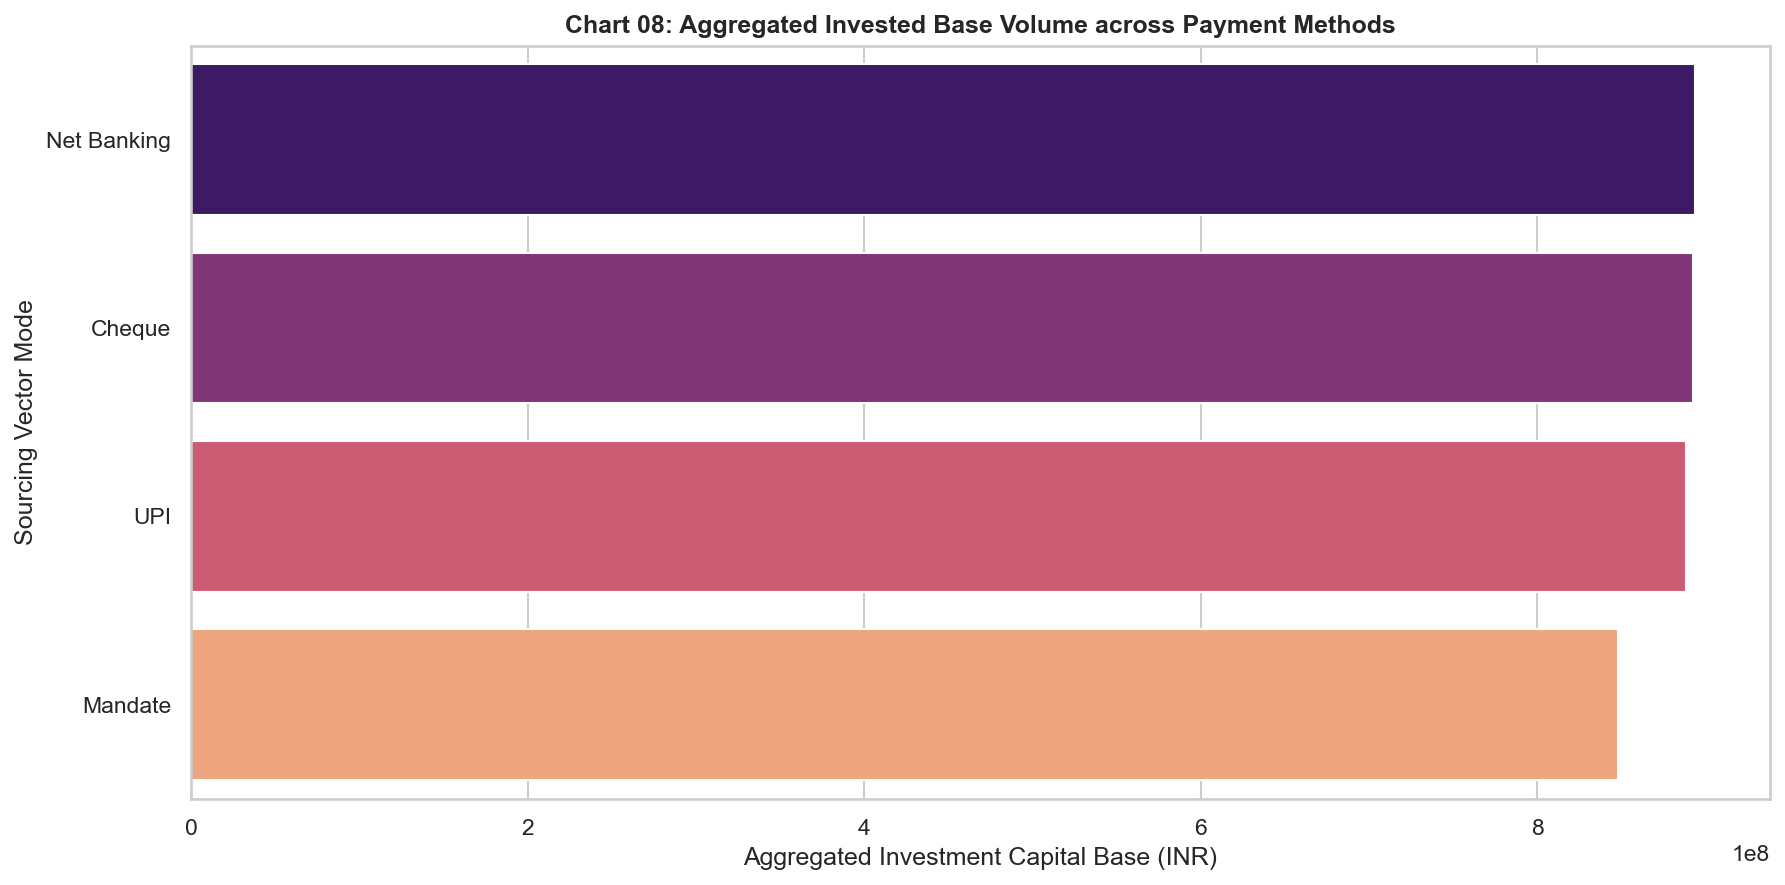

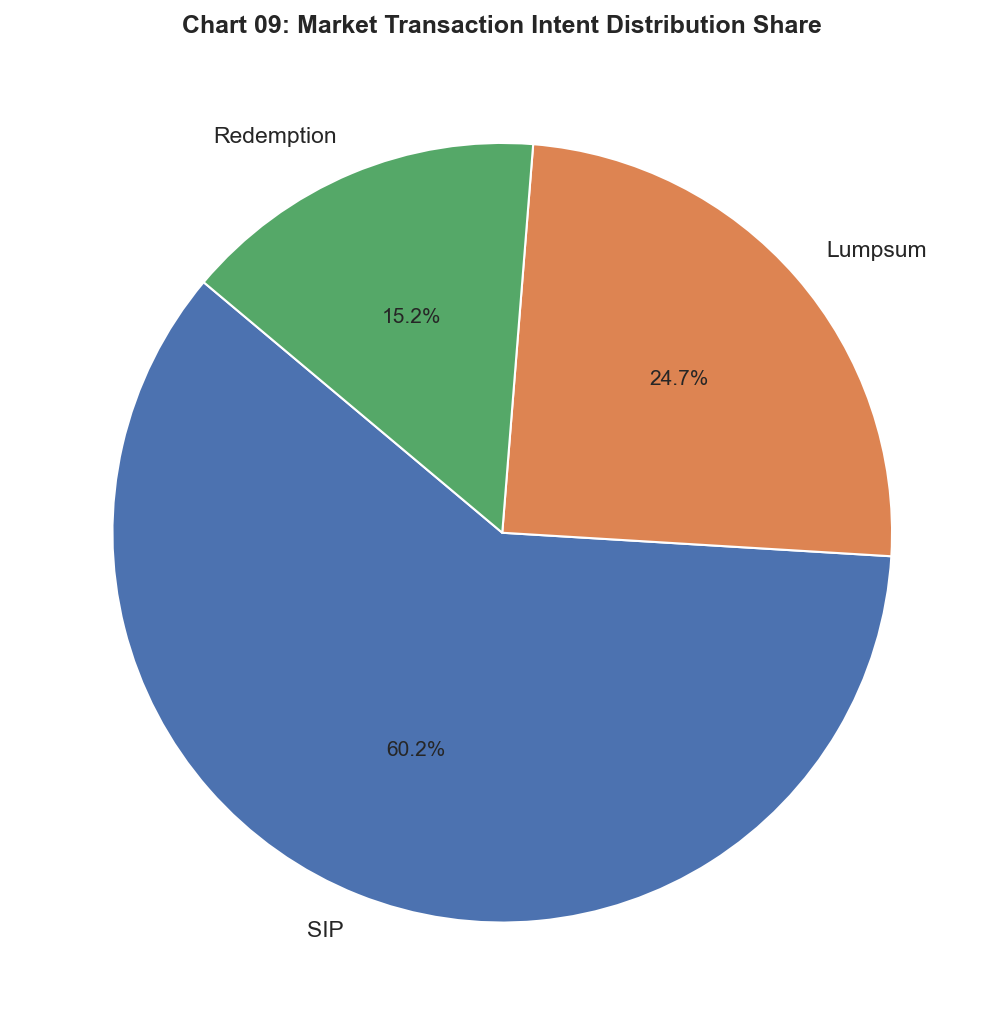

In [4]:
# Chart 08: Payment mode / amount concentration
plt.figure(figsize=(12, 6))
channel_amounts = fact_transactions.groupby('payment_mode')['amount_inr'].sum().sort_values(ascending=False)
sns.barplot(x=channel_amounts.values, y=channel_amounts.index, palette='magma')
plt.title('Chart 08: Aggregated Invested Base Volume across Payment Methods', fontweight='bold')
plt.xlabel('Aggregated Investment Capital Base (INR)')
plt.ylabel('Sourcing Vector Mode')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'geography.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 09: Transaction intent distribution (pie)
plt.figure(figsize=(7, 7))
type_dist2 = fact_transactions['transaction_type'].value_counts()
plt.pie(type_dist2, labels=type_dist2.index.astype(str), autopct='%1.1f%%', startangle=140)
plt.title('Chart 09: Market Transaction Intent Distribution Share', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'geography_tier.png', dpi=300, bbox_inches='tight')
plt.show()


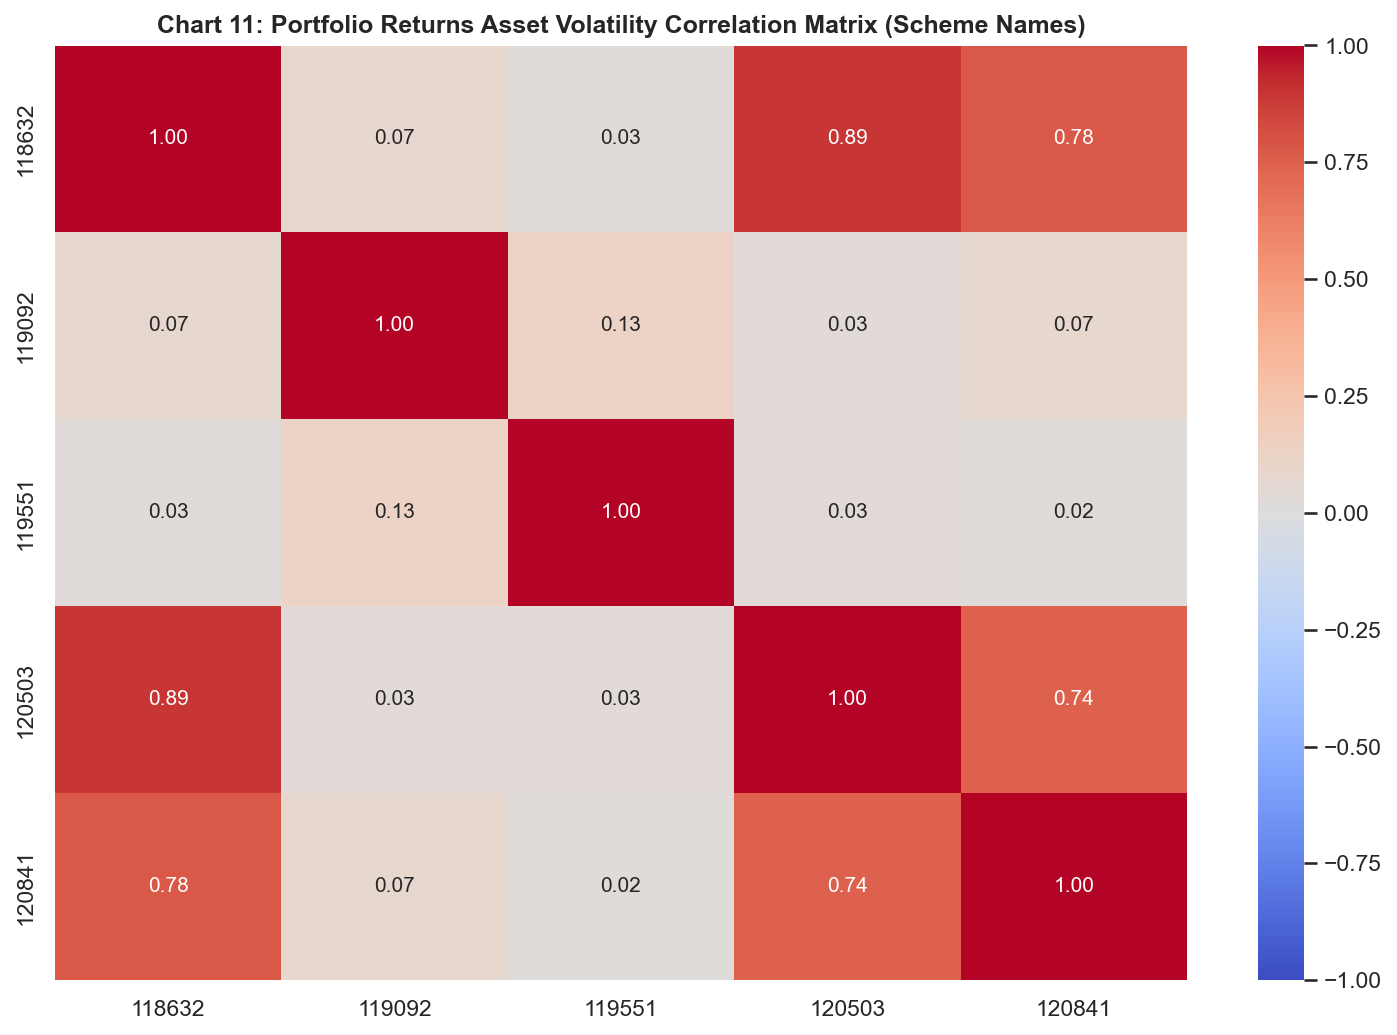

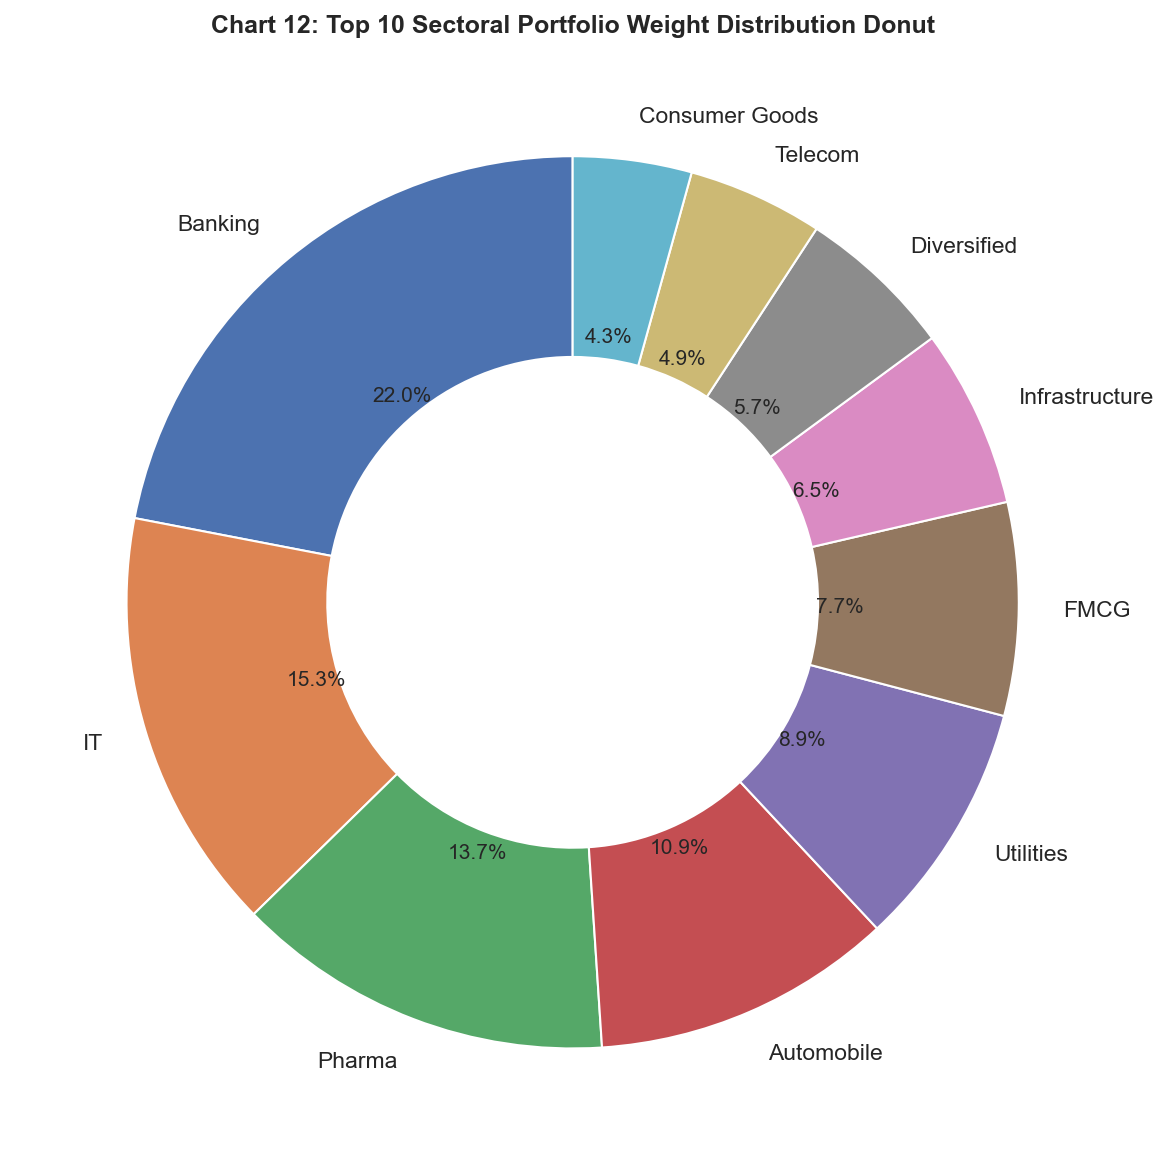

In [5]:
# Chart 10: Folio growth with milestones
folio_df = clean_folio_count.copy()
folio_df['month'] = folio_df['month'].astype(str)
fig_folio = px.line(folio_df.sort_values('month'), x='month', y='total_folios_crore',
                     title='Chart 10: Industry Folio Account Expansion Trend')
milestones = [('Jan 2022', 13.26), (None, 20.0), ('Dec 2025', 26.12)]
for m, val in milestones:
    if m is not None and m in folio_df['month'].values:
        row = folio_df[folio_df['month'] == m].iloc[0]
        fig_folio.add_annotation(x=row['month'], y=row['total_folios_crore'], text=f'{val:.2f} Cr',
                                 showarrow=True, arrowhead=1, bgcolor='lightgreen')
    else:
        idx = (folio_df['total_folios_crore'] - float(val)).abs().idxmin()
        row = folio_df.loc[idx]
        fig_folio.add_annotation(x=row['month'], y=row['total_folios_crore'], text=f'{val:.2f} Cr',
                                 showarrow=True, arrowhead=1, bgcolor='lightgreen')
fig_folio.update_layout(xaxis_title='Operating Calendar Month Line', yaxis_title='Total Live Folio Accounts (In Crores)')
fig_folio.write_image(str(REPORTS_CHARTS_DIR / 'folio_growth.png'), width=1920, height=1080, scale=2)
fig_folio.show()

# Chart 11: Correlation matrix with scheme_name labels from dim_fund
corr_df = fact_nav[fact_nav['scheme_code'].isin([119551, 120503, 118632, 119092, 120841])].pivot(
    index='date', columns='scheme_code', values='nav'
)
corr = corr_df.copy()
corr.index = pd.to_datetime(corr.index)
corr = corr.pct_change().corr()

scheme_map = (dim_fund.drop_duplicates('scheme_code').set_index('scheme_code')['scheme_name'].to_dict())
def map_name(x):
    v = scheme_map.get(x)
    if v is None or v == '' or str(v).lower() == 'nan':
        return str(x)
    return v
corr.columns = [map_name(c) for c in corr.columns]
corr.index = [map_name(c) for c in corr.index]

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Chart 11: Portfolio Returns Asset Volatility Correlation Matrix (Scheme Names)', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 12: Sector donut
plt.figure(figsize=(8, 8))
sector_w = clean_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)
plt.pie(sector_w, labels=sector_w.index.astype(str), autopct='%1.1f%%', wedgeprops=dict(width=0.45), startangle=90)
plt.title('Chart 12: Top 10 Sectoral Portfolio Weight Distribution Donut', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'sector_donut.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_57572/1863635270.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fact_transactions, x='payment_mode', palette='Set3', order=fact_transactions['payment_mode'].value_counts().index)


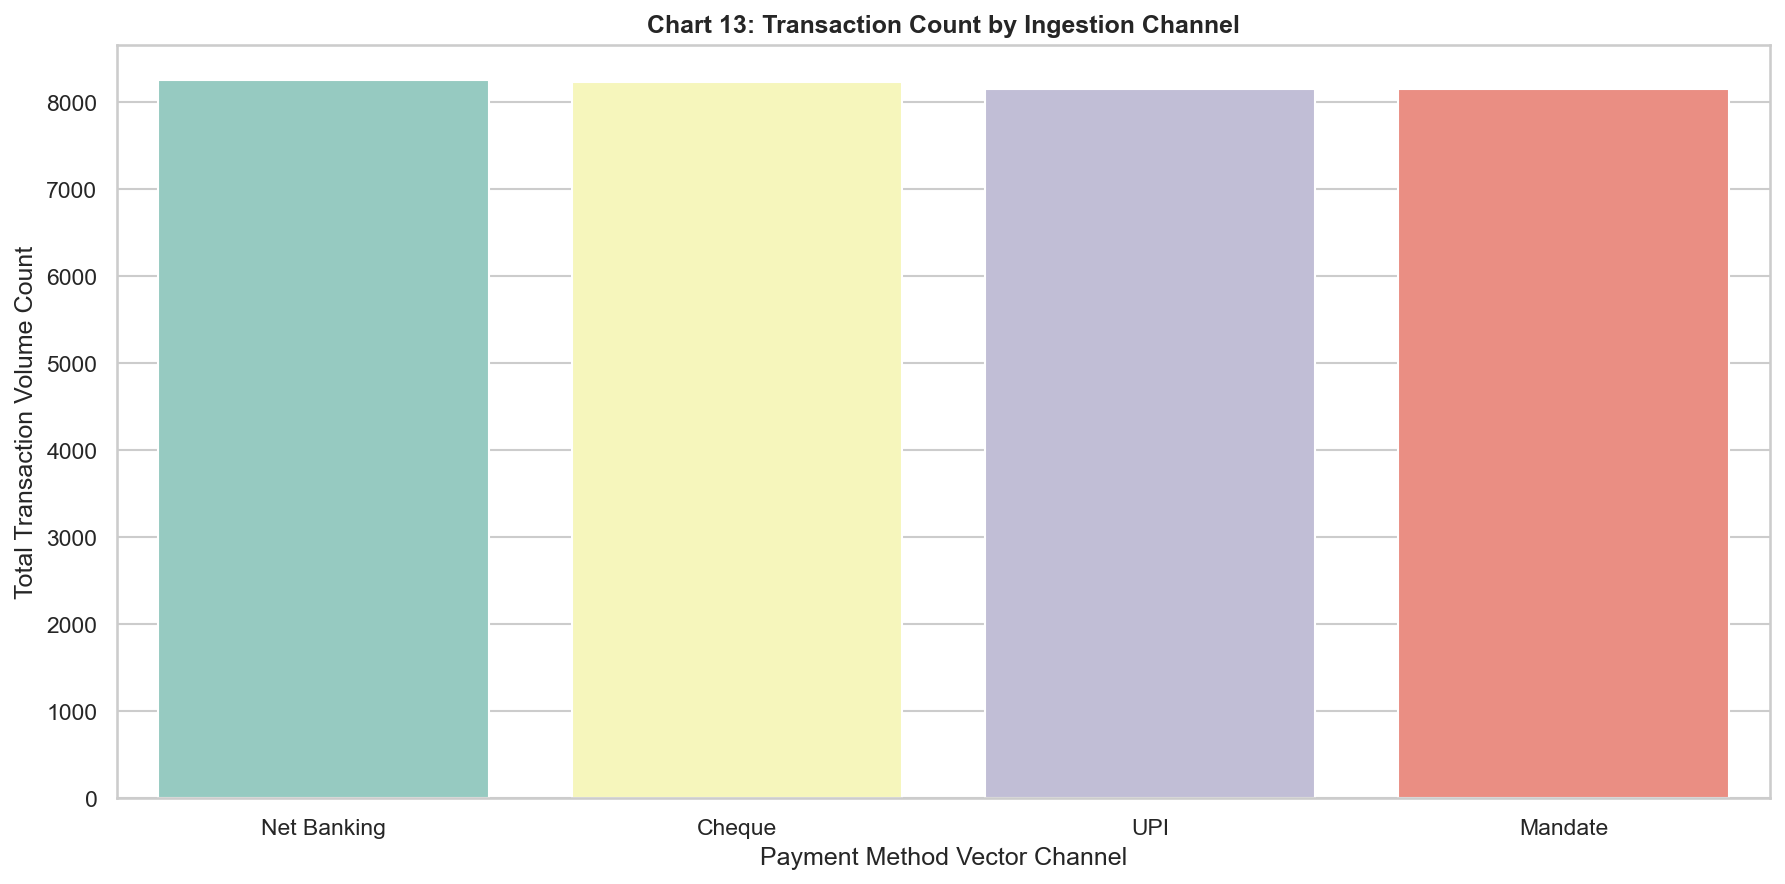

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_57572/1863635270.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fact_transactions, x='payment_mode', y='amount_inr', estimator=np.median,


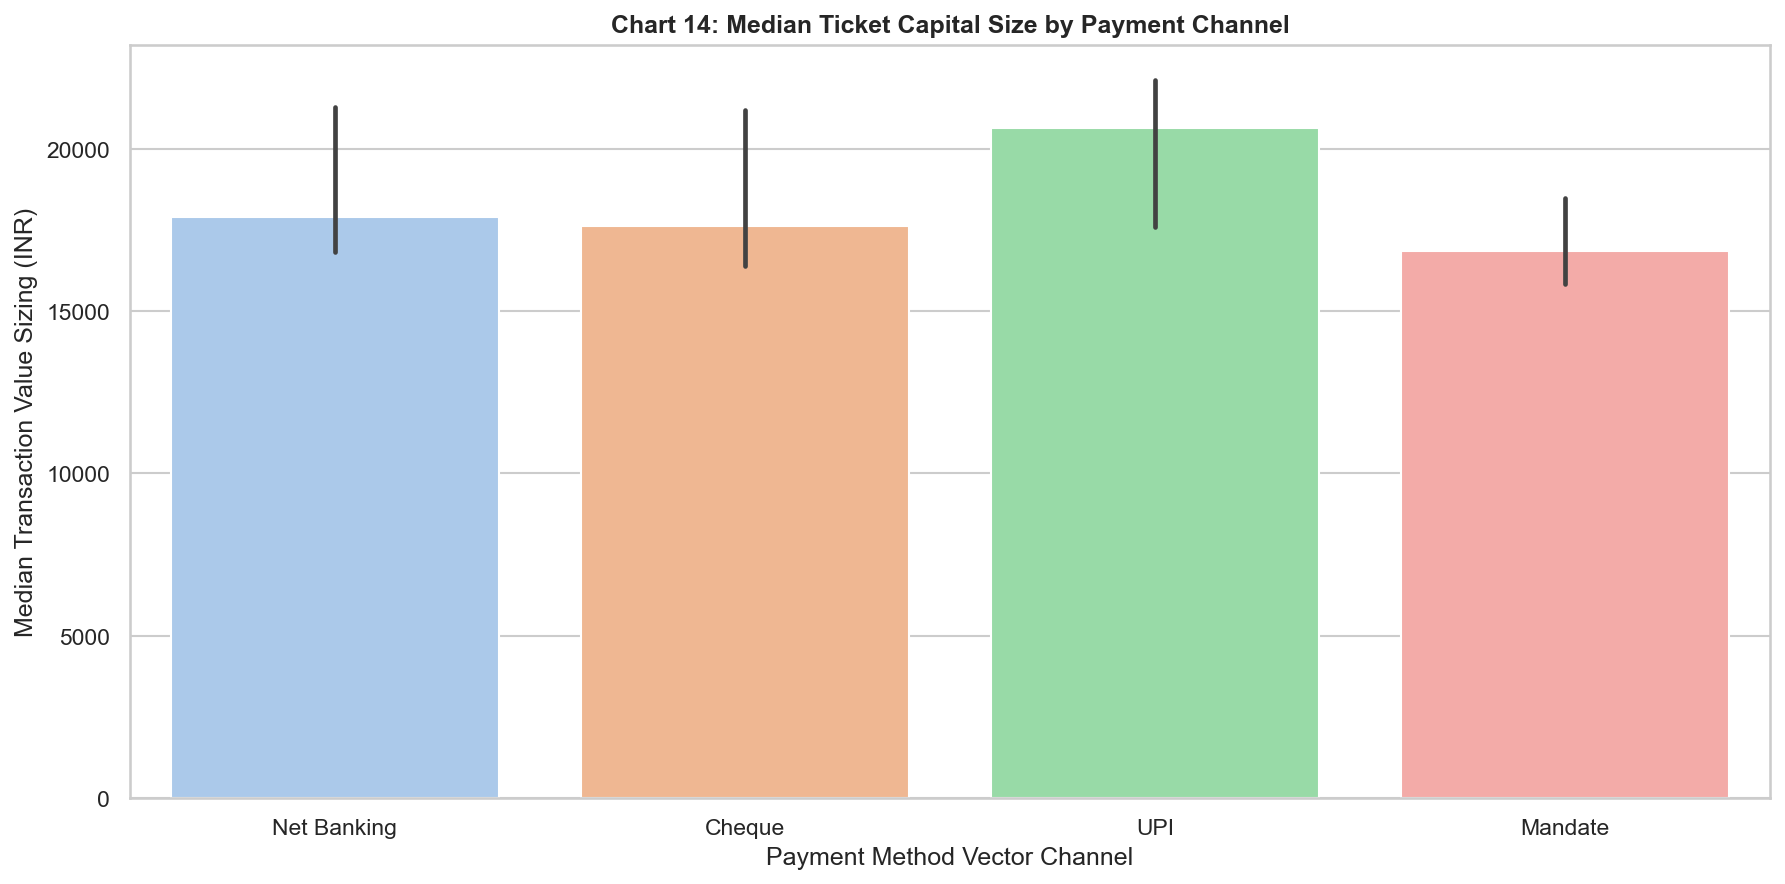

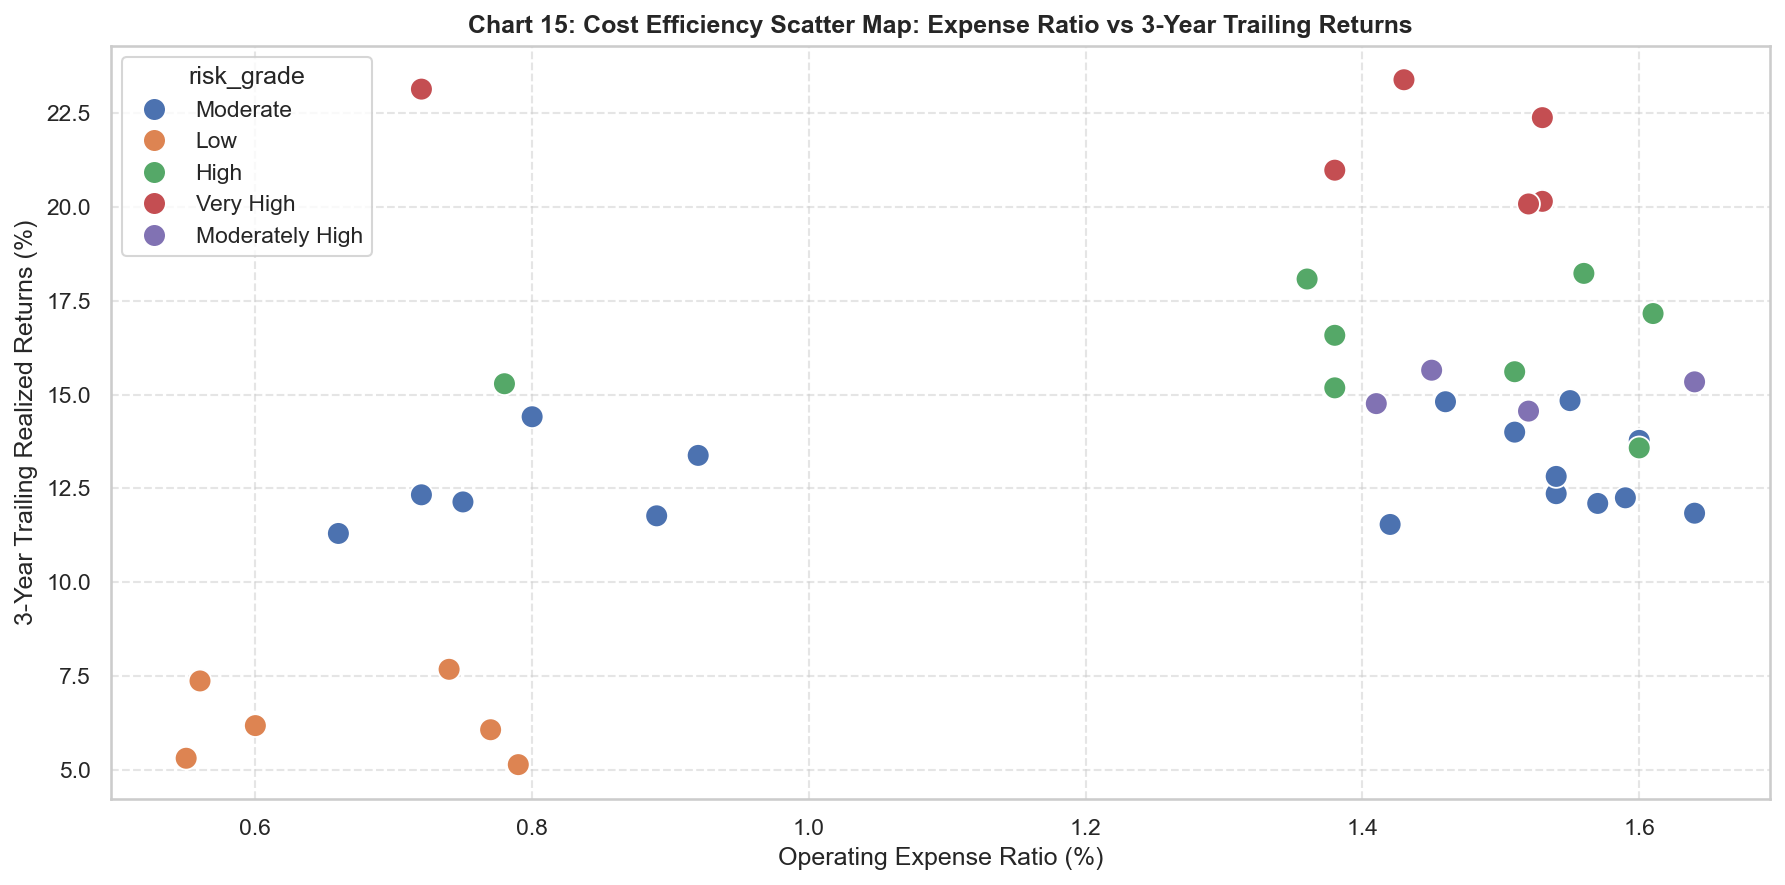

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_57572/1863635270.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fact_performance, x='risk_grade', y='sharpe_ratio', palette='Set3', order=risk_order)


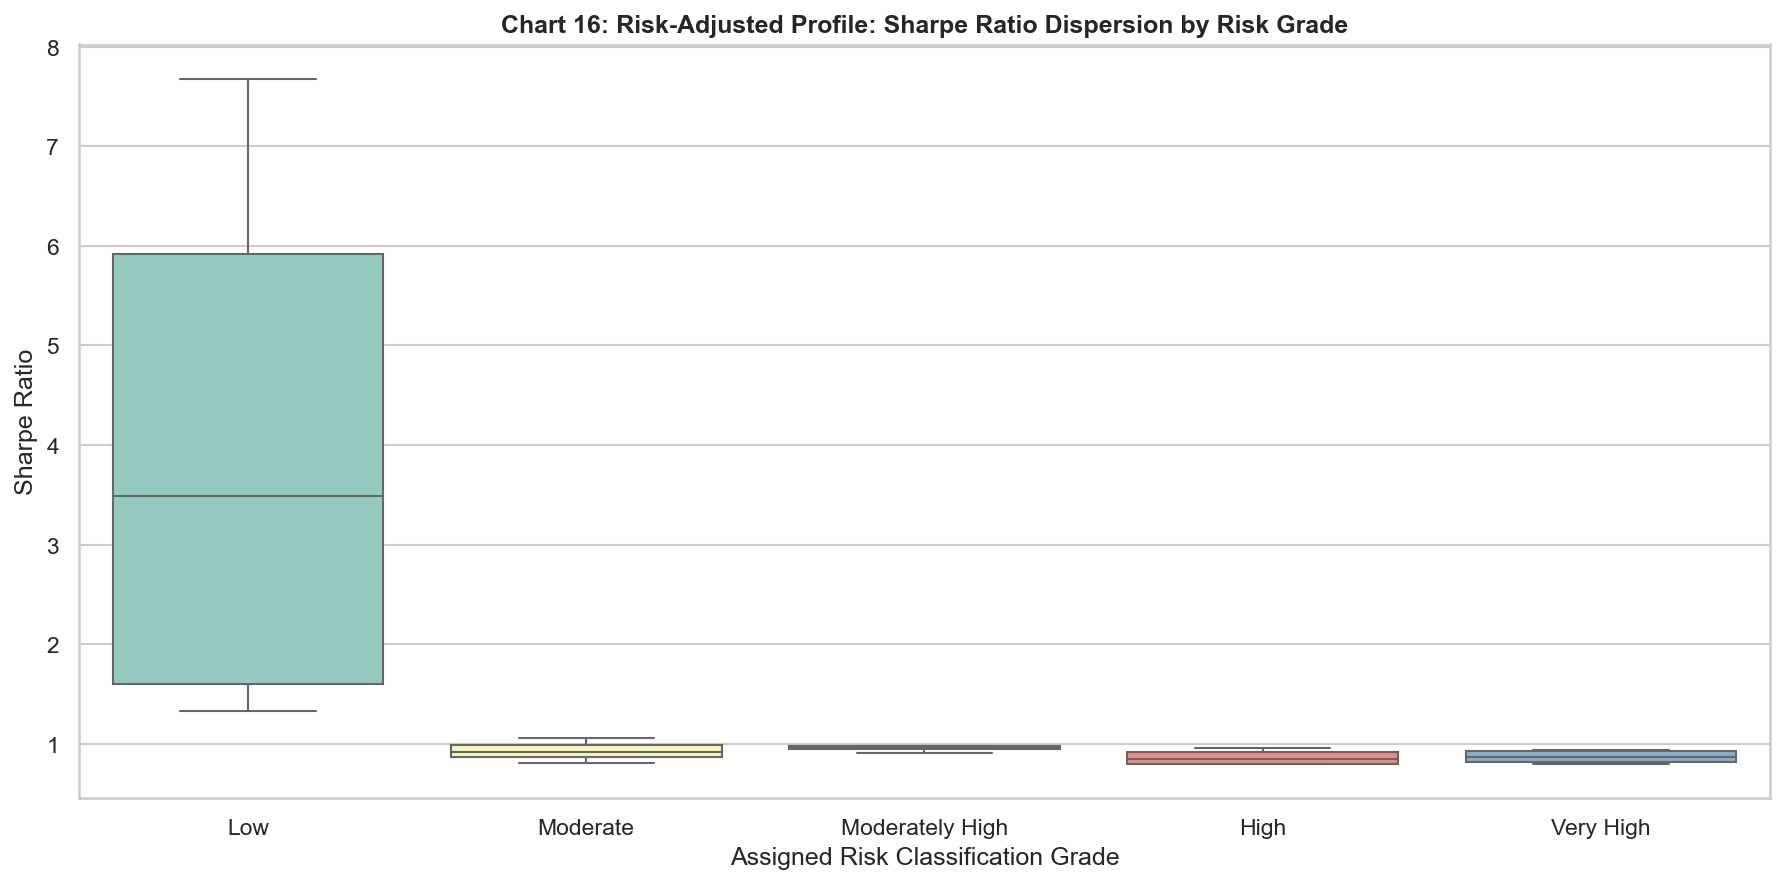

In [6]:
# Chart 13: Payment mode frequency
plt.figure(figsize=(12, 6))
sns.countplot(data=fact_transactions, x='payment_mode', palette='Set3', order=fact_transactions['payment_mode'].value_counts().index)
plt.title('Chart 13: Transaction Count by Ingestion Channel', fontweight='bold')
plt.xlabel('Payment Method Vector Channel')
plt.ylabel('Total Transaction Volume Count')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'payment_mode_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 14: Payment mode median ticket
plt.figure(figsize=(12, 6))
sns.barplot(data=fact_transactions, x='payment_mode', y='amount_inr', estimator=np.median,
            palette='pastel', order=fact_transactions['payment_mode'].value_counts().index)
plt.title('Chart 14: Median Ticket Capital Size by Payment Channel', fontweight='bold')
plt.xlabel('Payment Method Vector Channel')
plt.ylabel('Median Transaction Value Sizing (INR)')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'payment_mode_median_amount.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 15: Expense ratio vs 3Y return
plt.figure(figsize=(12, 6))
sns.scatterplot(data=fact_performance, x='expense_ratio_pct', y='return_3yr_pct', hue='risk_grade', s=120, palette='deep')
plt.title('Chart 15: Cost Efficiency Scatter Map: Expense Ratio vs 3-Year Trailing Returns', fontweight='bold')
plt.xlabel('Operating Expense Ratio (%)')
plt.ylabel('3-Year Trailing Realized Returns (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'cost_efficiency_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 16: Sharpe by risk grade
plt.figure(figsize=(12, 6))
risk_order = [x for x in ['Low', 'Moderate', 'Moderately High', 'High', 'Very High'] if x in fact_performance['risk_grade'].unique()]
if not risk_order:
    risk_order = sorted([x for x in fact_performance['risk_grade'].dropna().unique()])
sns.boxplot(data=fact_performance, x='risk_grade', y='sharpe_ratio', palette='Set3', order=risk_order)
plt.title('Chart 16: Risk-Adjusted Profile: Sharpe Ratio Dispersion by Risk Grade', fontweight='bold')
plt.xlabel('Assigned Risk Classification Grade')
plt.ylabel('Sharpe Ratio')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'sharpe_ratio_by_risk_grade.png', dpi=300, bbox_inches='tight')
plt.show()


## Summary of 10 Key EDA Findings

(Text placeholder retained from original notebook.)
